In [1]:
import os, re, glob, math, time, random
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageOps
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
seed_everything(42)

In [4]:
DATA_DIR = Path(r"E:\multiview_pig_posture_recognition")
print("DATA_DIR:", DATA_DIR)
train_csv = DATA_DIR / (f"train1.csv")
train1_img_dir = DATA_DIR / "train1_images"

DATA_DIR: E:\multiview_pig_posture_recognition


Use photos taken in 20250209 as test

In [5]:
train_df = pd.read_csv(train_csv)
mask_test = train_df["image_id"].str.contains(r"_20250209_")
test_df = train_df.loc[mask_test].copy()
train_df = train_df.loc[~mask_test].copy()

In [6]:
train_df = train_df.sort_values("image_id")
classes_txt = DATA_DIR / "pig_posture_classes.txt"
with open(classes_txt, "r") as f:
        CLASS_NAMES = [line.strip() for line in f if line.strip()]
pd.DataFrame({
    "label": range(5),
    "class_name": CLASS_NAMES
})

,label,class_name
0,0,Lateral_lying_left
1,1,Lateral_lying_right
2,2,Sitting
3,3,Standing
4,4,Sternal_lying


In [7]:
def parse_cam_type(image_id: str):
    m = re.search(r"_([a-zA-Z]+)_cam\d+_", str(image_id))
    return m.group(1).lower() if m else "unk"
train_df["cam_type"] = train_df["image_id"].map(parse_cam_type)
test_df["cam_type"]  = test_df["image_id"].map(parse_cam_type)

In [8]:
def parse_bbox_string(bbox_str):
    s = str(bbox_str).strip()
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()
    s = s.replace(",", " ")
    parts = [p for p in s.split() if p]
    if len(parts) != 4:
        raise ValueError(f"Bad bbox: {bbox_str}")
    x, y, w, h = map(float, parts)
    return x, y, w, h

bx = train_df["bbox"].apply(parse_bbox_string)
train_df["x"] = bx.apply(lambda t: t[0])
train_df["y"] = bx.apply(lambda t: t[1])
train_df["w"] = bx.apply(lambda t: t[2])
train_df["h"] = bx.apply(lambda t: t[3])

bx = test_df["bbox"].apply(parse_bbox_string)
test_df["x"] = bx.apply(lambda t: t[0])
test_df["y"] = bx.apply(lambda t: t[1])
test_df["w"] = bx.apply(lambda t: t[2])
test_df["h"] = bx.apply(lambda t: t[3])

# EDA

In [9]:
def parse_scene(image_id):
    parts = image_id.split("_")

    pen  = parts[0]        # pen1/pen2
    date = parts[3]        # 20250108 date

    return f"{pen}_{date}"

In [10]:
train_df["datetime"] = pd.to_datetime(
    train_df["image_id"].str.extract(r'(\d{8}_\d{6})')[0],
    format="%Y%m%d_%H%M%S"
)
train_df = train_df.sort_values(["cam_type", "datetime"]).reset_index(drop=True)
train_df["time_diff_sec"] = (
    train_df.groupby("cam_type")["datetime"]
    .diff()
    .dt.total_seconds()
)
print(train_df["time_diff_sec"].describe())

count     21188.000000
mean        172.953889
std        9365.933857
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      946584.000000
Name: time_diff_sec, dtype: float64


In [11]:
bins = [0, 5, 10, 30, 60, 120, 300, 600, 1800, 3600, 999999]

labels = [
    "0-5s",
    "5-10s",
    "10-30s",
    "30-60s",
    "1-2min",
    "2-5min",
    "5-10min",
    "10-30min",
    "30-60min",
    ">1h"
]

train_df["diff_bucket"] = pd.cut(
    train_df["time_diff_sec"],
    bins=bins,
    labels=labels
)

print(train_df["diff_bucket"].value_counts().sort_index())

diff_bucket
0-5s        723
5-10s       802
10-30s        7
30-60s        1
1-2min      633
2-5min      638
5-10min       9
10-30min     17
30-60min      1
>1h          15
Name: count, dtype: int64


To avoid data leakage caused by short time window (e.g., two pictures taken in 10s successively), Any two images, provided that the time difference is less than 45 seconds and are both taken by the same camera , must be entered into the train or the val as a whole and cannot be separated.

In [12]:
train_df = train_df.sort_values(["cam_type", "datetime"]).reset_index(drop=True)
time_threshold = 45  # time window
group_ids = []
current_group = 0

for cam in train_df["cam_type"].unique():

    cam_idx = train_df["cam_type"] == cam
    cam_df = train_df[cam_idx]

    last_time = None

    for idx in cam_df.index:
        current_time = train_df.loc[idx, "datetime"]
        if last_time is None:
            group_ids.append(current_group)
        else:
            diff = (current_time - last_time).total_seconds()
            if diff <= time_threshold:
                group_ids.append(current_group)
            else:
                current_group += 1
                group_ids.append(current_group)

        last_time = current_time

    current_group += 1

train_df["time_group"] = group_ids

In [13]:
img_dom = (
    train_df
    .groupby("image_id") # avoid data leakage, separate pictures, instead of patch into train/test
    .agg(dom_label=("class_id", lambda s: s.value_counts().idxmax()), # select the largest class group to represent the picture
         cam_type=("cam_type", "first"), # a picture is taken by a specific angle, which means that the camera type should be identical
            time_group=("time_group", "first"))
    .reset_index()
)

img_dom["scene_time_group"] = (
    img_dom["cam_type"].astype(str)
    + "_"
    + img_dom["time_group"].astype(str)
)

In [14]:
from sklearn.model_selection import StratifiedGroupKFold
train_df_new = []
val_df_new =[]
sgkf = StratifiedGroupKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

splits = list(
    sgkf.split(
        img_dom,
        y=img_dom["dom_label"], # This tells the splitter to maintain the class distribution of dom_label across the folds.
        groups=img_dom["scene_time_group"] # all samples belonging to the same group are assigned to the same fold.
    )
)

train_idx, val_idx = splits[0]

train_imgs = set(img_dom.iloc[train_idx]["image_id"])
val_imgs   = set(img_dom.iloc[val_idx]["image_id"])

train_df_new = train_df[train_df["image_id"].isin(train_imgs)].reset_index(drop=True)
val_df_new   = train_df[train_df["image_id"].isin(val_imgs)].reset_index(drop=True)

E:\multiview_pig_posture_recognition\.venv3\lib\site-packages\sklearn\model_selection\_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


In [15]:
print("train:", train_df_new.shape, "test:", test_df.shape, "val:", val_df_new.shape)

train: (16678, 15) test: (1744, 11) val: (4512, 15)


In [16]:
train_df_new.head()

,row_id,image_id,width,height,bbox,class_id,cam_type,x,y,w,h,datetime,time_diff_sec,diff_bucket,time_group
0,train_pen1_orb_cam2_20250108_080108_0004,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[817.7,0.0,262.0,264.3]",3,orb,817.7,0.0,262.0,264.3,2025-01-08 08:01:08,NaN,NaN,0
1,train_pen1_orb_cam2_20250108_080108_0005,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[428.0,416.0,243.0,433.0]",4,orb,428.0,416.0,243.0,433.0,2025-01-08 08:01:08,0.0,NaN,0
2,train_pen1_orb_cam2_20250108_080108_0002,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[1204.5,4.0,209.0,296.0]",3,orb,1204.5,4.0,209.0,296.0,2025-01-08 08:01:08,0.0,NaN,0
3,train_pen1_orb_cam2_20250108_080108_0000,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[987.0,314.5,447.0,472.0]",3,orb,987.0,314.5,447.0,472.0,2025-01-08 08:01:08,0.0,NaN,0
4,train_pen1_orb_cam2_20250108_080108_0001,pen1_orb_cam2_20250108_080108.jpg,1920,1080,"[559.5,199.0,296.0,417.0]",3,orb,559.5,199.0,296.0,417.0,2025-01-08 08:01:08,0.0,NaN,0


We pretend that the data structure in test is unknown and may suffer from data drift. Therefore, our model must be robust.

The val is separated to ensure that the distribution of class id and camera type to be identical. Moreover, , photos taken on the same date are either assigned to the val set or the training set.

## pig numeber classifcation

pig_count
9     0.318940
5     0.257802
8     0.169303
4     0.091065
10    0.076101
7     0.047884
3     0.026507
6     0.011971
11    0.000428
Name: proportion, dtype: float64


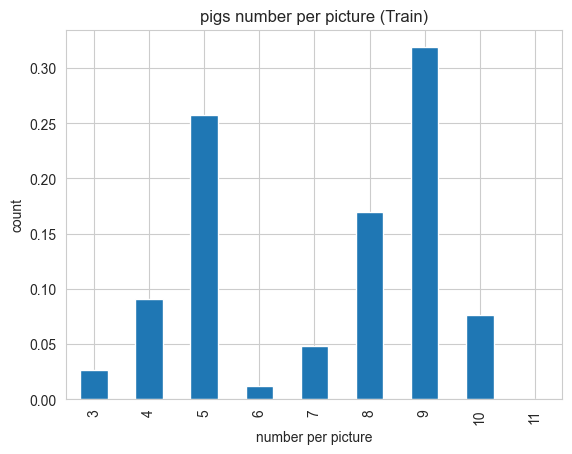

In [17]:
pig_count_df = (
    train_df_new
    .groupby("image_id")
    .size()
    .reset_index(name="pig_count")
)

pig_count_df["pig_count"].value_counts(normalize=True).sort_index().plot(kind = "bar")
plt.title(f"pigs number per picture (Train)")
plt.xlabel("number per picture")
plt.ylabel("count")
print(pig_count_df["pig_count"].value_counts(normalize=True))

pig_count
8     0.579892
9     0.202873
10    0.104129
5     0.046679
4     0.034111
7     0.021544
6     0.008977
11    0.001795
Name: proportion, dtype: float64


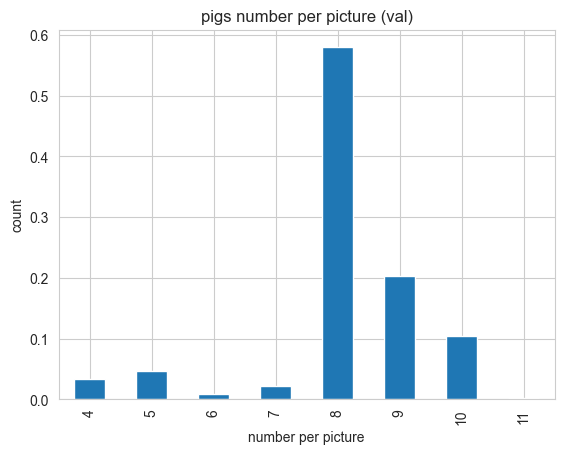

In [18]:
pig_count_df = (
    val_df_new
    .groupby("image_id")
    .size()
    .reset_index(name="pig_count")
)

pig_count_df["pig_count"].value_counts(normalize=True).sort_index().plot(kind = "bar")
plt.title(f"pigs number per picture (val)")
plt.xlabel("number per picture")
plt.ylabel("count")
print(pig_count_df["pig_count"].value_counts(normalize=True))

## class distribution

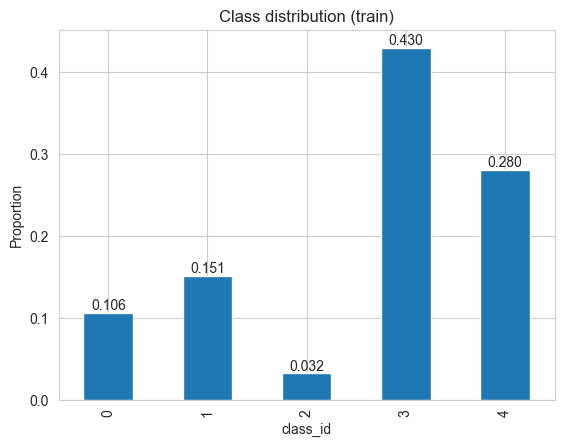

In [19]:
ratio = (
    train_df_new["class_id"]
    .value_counts(normalize=True)
    .sort_index()
)

ax = ratio.plot(kind="bar")

plt.title("Class distribution (train)")
plt.xlabel("class_id")
plt.ylabel("Proportion")

ax.bar_label(ax.containers[0], fmt="%.3f")

plt.show()

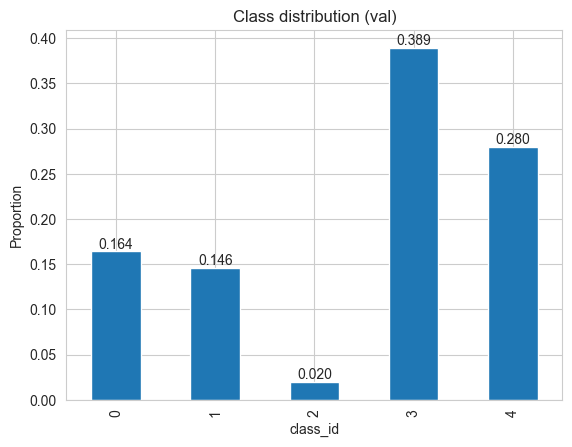

In [20]:
ratio = (
    val_df_new["class_id"]
    .value_counts(normalize=True)
    .sort_index()
)

ax = ratio.plot(kind="bar")

plt.title("Class distribution (val)")
plt.xlabel("class_id")
plt.ylabel("Proportion")

ax.bar_label(ax.containers[0], fmt="%.3f")

plt.show()

Because we assign the class label of each image based on the majority pig type appearing in that photo, the final class distribution is determined by the dominant category rather than individual pig instances. Therefore, it is necessary to examine whether the class proportions in the full dataset, as well as in the train and test splits, remain consistent, in order to avoid unintended distribution shift and ensure reliable model evaluation.

## camera type distribution

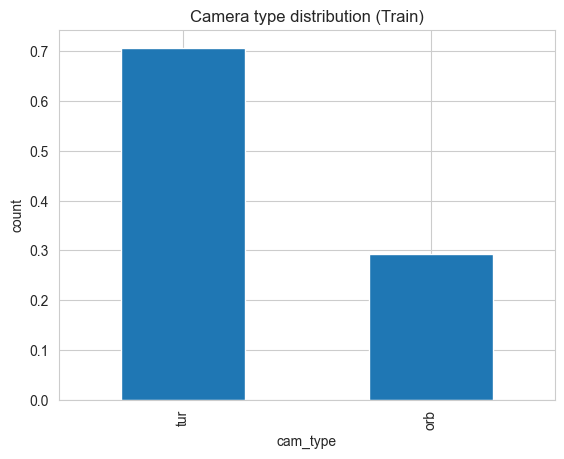

In [21]:
plt.figure()
train_df_new["cam_type"].value_counts(normalize=True).plot(kind="bar")
plt.title(f"Camera type distribution (Train)")
plt.xlabel("cam_type")
plt.ylabel("count")
plt.show()

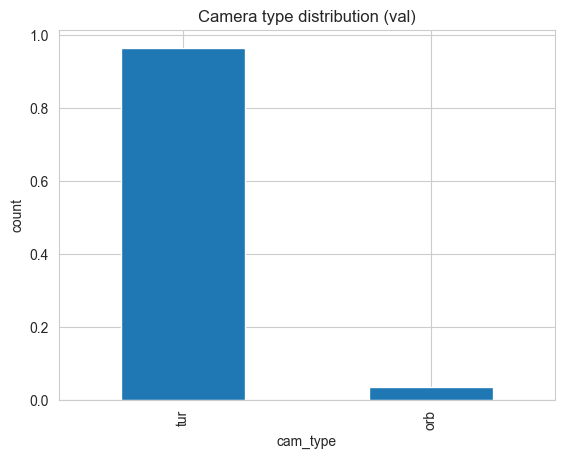

In [22]:
plt.figure()
val_df_new["cam_type"].value_counts(normalize=True).plot(kind="bar")
plt.title(f"Camera type distribution (val)")
plt.xlabel("cam_type")
plt.ylabel("count")
plt.show()

## bbox statistics

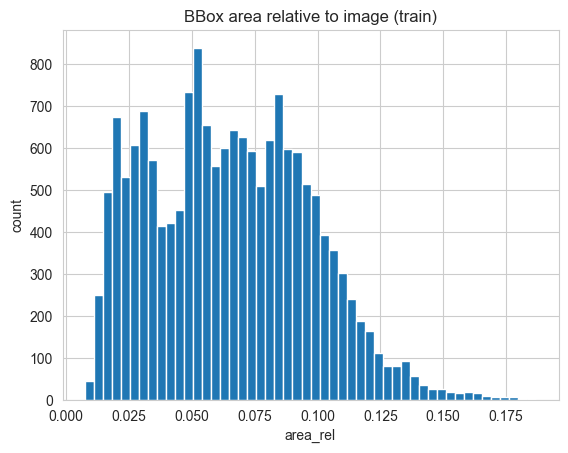

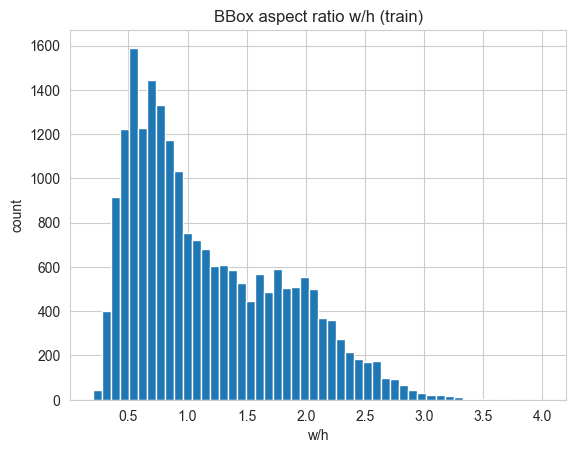

In [23]:
fig, ax = plt.subplots()
area_rel = (train_df_new["w"] * train_df_new["h"]) / (train_df_new["width"] * train_df_new["height"])
ax.hist(area_rel.values, bins=50)
ax.set_title("BBox area relative to image (train)")
ax.set_xlabel("area_rel")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots()
ar = train_df["w"] / np.clip(train_df["h"], 1e-6, None)
ax.hist(ar.values, bins=50)
ax.set_title("BBox aspect ratio w/h (train)")
ax.set_xlabel("w/h")
ax.set_ylabel("count")
plt.show()


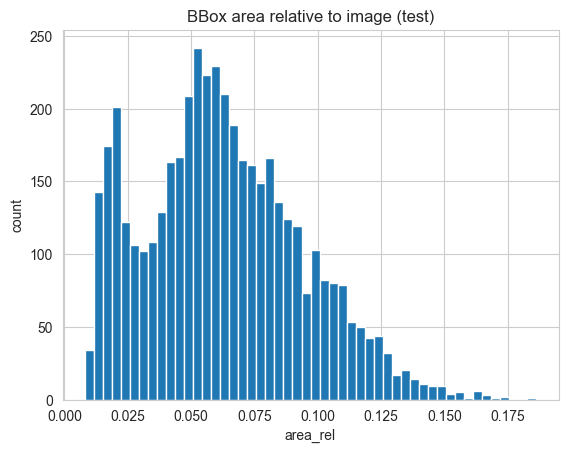

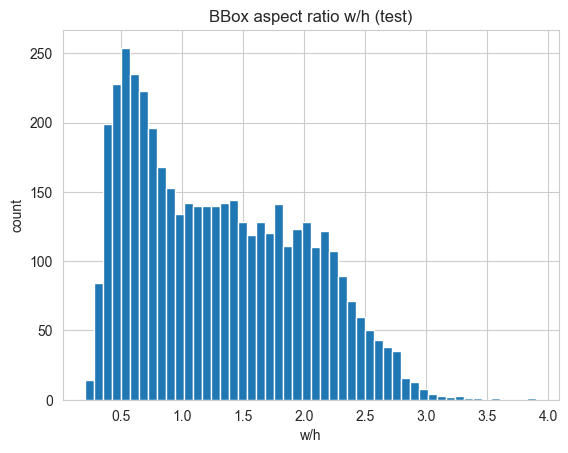

In [24]:
fig, ax = plt.subplots()
area_rel = (val_df_new["w"] * val_df_new["h"]) / (val_df_new["width"] * val_df_new["height"])
ax.hist(area_rel.values, bins=50)
ax.set_title("BBox area relative to image (test)")
ax.set_xlabel("area_rel")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots()
ar = val_df_new["w"] / np.clip(val_df_new["h"], 1e-6, None)
ax.hist(ar.values, bins=50)
ax.set_title("BBox aspect ratio w/h (test)")
ax.set_xlabel("w/h")
ax.set_ylabel("count")
plt.show()


# random sample

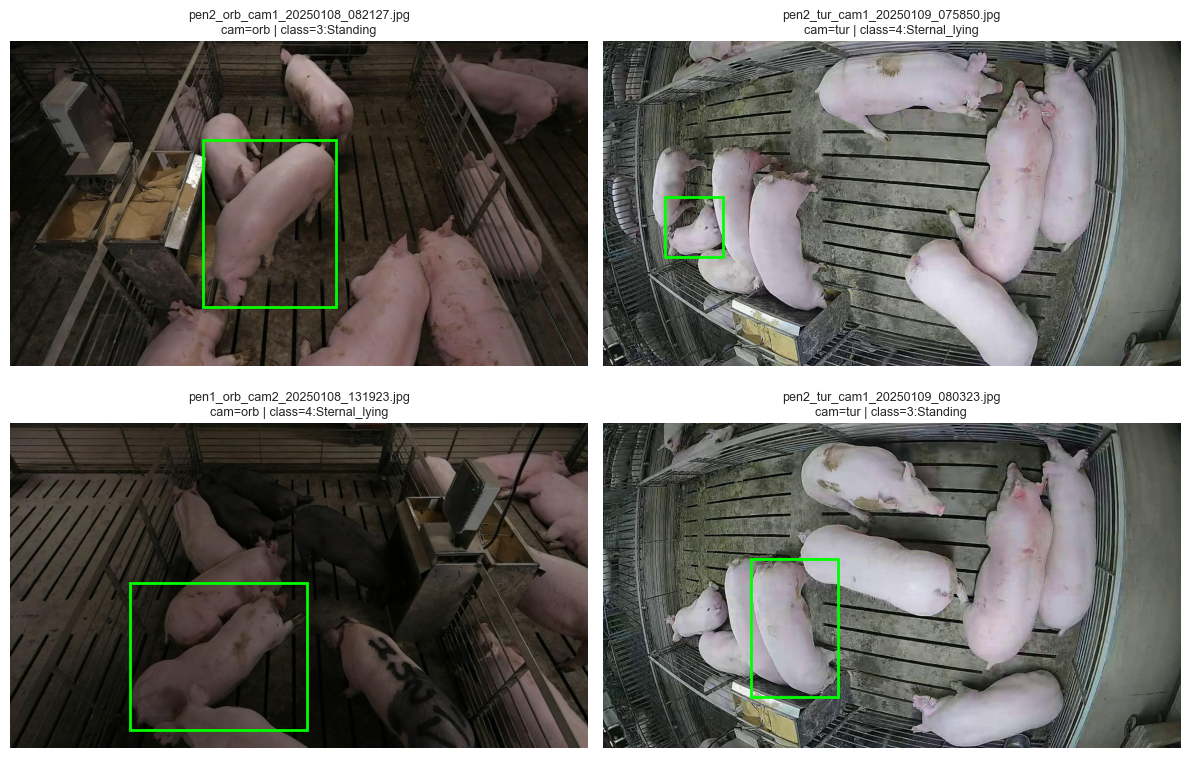

In [25]:
def show_train_samples(n=4, seed=0):
    rnd = np.random.RandomState(seed)
    idxs = rnd.choice(len(train_df), size=n , replace=False)

    cols = 2
    rows = int(np.ceil(len(idxs)/cols))
    plt.figure(figsize=(cols*6, rows*4))

    for i, idx in enumerate(idxs, 1):
        r = train_df.iloc[idx]
        img_path = train1_img_dir / r["image_id"]
        img = Image.open(img_path).convert("RGB")
        x, y, w, h = parse_bbox_string(r["bbox"])

        ax = plt.subplot(rows, cols, i)
        ax.imshow(img)
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)

        cid = int(r["class_id"])
        title = f'{r["image_id"]}\ncam={r["cam_type"]} | class={cid}:{CLASS_NAMES[cid]}'
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
show_train_samples(n=4, seed=42)

# what the model actually see (chopping the image)

In [26]:
def pad_to_square(pil_img):
    pil_img.thumbnail((224, 224), Image.BICUBIC) # Resize the image to 224 pixels while preserving the original aspect ratio.
    w, h = pil_img.size
    pad_w = 224 - w
    pad_h = 224 - h
    left = pad_w // 2
    right = pad_w - left
    top = pad_h // 2
    bottom = pad_h - top
    img_np = np.array(pil_img)

    border = 10  # Use average color of 10 pixels from each edge of the image.
    top_edge = img_np[:border, :, :]
    bottom_edge = img_np[-border:, :, :]
    left_edge = img_np[:, :border, :]
    right_edge = img_np[:, -border:, :]

    edge_pixels = np.concatenate([
        top_edge.reshape(-1,3),
        bottom_edge.reshape(-1,3),
        left_edge.reshape(-1,3),
        right_edge.reshape(-1,3)
    ], axis=0)

    mean_color = tuple(np.mean(edge_pixels, axis=0).astype(int))

    padded = ImageOps.expand(
        pil_img,
        border=(left, top, right, bottom),
        fill=mean_color
    )

    return padded

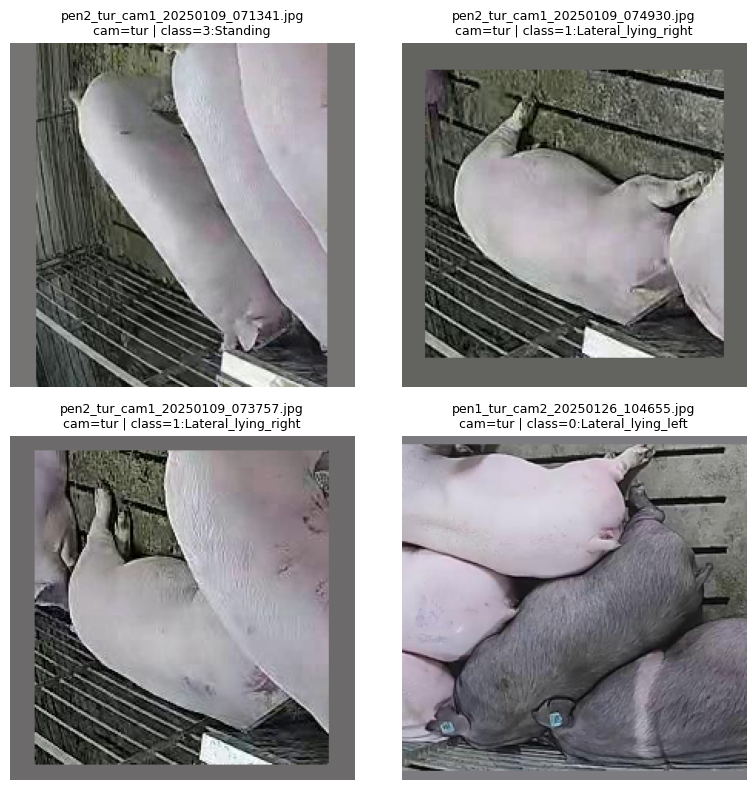

In [27]:
def show_train_crops(seed=0, pad_ratio=0.12):
    rnd = np.random.RandomState(seed)
    idxs = rnd.choice(len(train_df), size=min(4, len(train_df)), replace=False)
    plt.style.use("default")
    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs, 1):
        r = train_df.iloc[idx]
        img = Image.open(train1_img_dir / r["image_id"]).convert("RGB")
        W, H = img.size
        x, y, w, h = parse_bbox_string(r["bbox"])

        pad = pad_ratio * max(w, h) # longer width

        x1 = max(0, int(x - pad))
        y1 = max(0, int(y - pad))
        x2 = min(W, int(x + w + pad))
        y2 = min(H, int(y + h + pad))

        crop = img.crop((x1, y1, x2, y2))
        crop = pad_to_square(crop)

        ax = plt.subplot(2, 2, i)
        ax.imshow(crop)
        cid = int(r["class_id"])
        title = f'{r["image_id"]}\ncam={r["cam_type"]} | class={cid}:{CLASS_NAMES[cid]}'
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_train_crops(seed=22)